In [ ]:
# -*- coding: utf-8 -*-
"""
Phi-4-mini-instruct QLoRA    Evaluation Notebook
===================================================
Loads the saved LoRA adapter + test split, runs inference, and reports:
  • Accuracy
  • Precision  (macro & weighted)
  • Recall     (macro & weighted)
  • F1-score   (macro & weighted)
  • Full per-class classification report
  • Confusion matrix (saved as PNG to Drive)

Run this in a SEPARATE Colab notebook AFTER fine-tuning is complete.
Runtime: GPU (A100 recommended, T4 works too).
"""

'\nPhi-4-mini-instruct QLoRA  —  Evaluation Notebook\n===================================================\nLoads the saved LoRA adapter + test split, runs inference, and reports:\n  • Accuracy\n  • Precision  (macro & weighted)\n  • Recall     (macro & weighted)\n  • F1-score   (macro & weighted)\n  • Full per-class classification report\n  • Confusion matrix (saved as PNG to Drive)\n\nRun this in a SEPARATE Colab notebook AFTER fine-tuning is complete.\nRuntime: GPU (A100 recommended, T4 works too).\n'

In [ ]:
# Install dependencies  (same pinned versions as training)

import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu124"],
               check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.48.1",
                "accelerate==1.3.0",
                "peft==0.14.0",
                "bitsandbytes>=0.43.0",
                "datasets>=2.18.0",
                "scikit-learn",
                "pandas",
                "numpy",
                "sentencepiece",
                "matplotlib",
                "seaborn"],
               check=True)

print("✅  Packages ready.")

✅  Packages ready.


In [ ]:

# Mount Drive & login to HuggingFace

from google.colab import drive
drive.mount("/content/drive")

from huggingface_hub import login
HF_TOKEN = "hf_*************************"   
login(HF_TOKEN)
print("✅  Drive mounted & HF login done.")

Mounted at /content/drive
✅  Drive mounted & HF login done.


In [ ]:
# Imports

import os, json, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("✅  Imports done.  GPU:", torch.cuda.get_device_name(0)
      if torch.cuda.is_available() else "none")

✅  Imports done.  GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Paths  (must match the training script exactly)
# ===========================================================================
BASE_MODEL_ID  = "microsoft/Phi-4-mini-instruct"

PROJECT_DIR    = "/content/drive/MyDrive/phi4_thesis_HuggingFace"
QLORA_DIR      = os.path.join(PROJECT_DIR, "qlora_model")
SPLITS_DIR     = os.path.join(PROJECT_DIR, "splits")
METRICS_DIR    = os.path.join(PROJECT_DIR, "metrics")
PREDICTIONS_DIR = os.path.join(PROJECT_DIR, "predictions")

for folder in [METRICS_DIR, PREDICTIONS_DIR]:
    os.makedirs(folder, exist_ok=True)

#  Load the label list saved during training 
labels_path = os.path.join(QLORA_DIR, "labels.json")
if not os.path.exists(labels_path):                       # fallback to splits dir
    labels_path = os.path.join(SPLITS_DIR, "labels.json")

with open(labels_path) as f:
    LABELS = json.load(f)

LABELS_LOWER = [l.lower().strip() for l in LABELS]

print("QLORA_DIR :", QLORA_DIR)
print("SPLITS_DIR:", SPLITS_DIR)
print("Labels    :", LABELS)

QLORA_DIR : /content/drive/MyDrive/phi4_thesis_HuggingFace/qlora_model
SPLITS_DIR: /content/drive/MyDrive/phi4_thesis_HuggingFace/splits
Labels    : ['applied', 'cited', 'considered', 'discussed', 'distinguished', 'followed', 'referred to']


In [ ]:
# ===========================================================================
# Load the test split
# ===========================================================================
TEXT_COL  = "case_text"
LABEL_COL = "case_outcome"

test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
test_df[TEXT_COL]  = test_df[TEXT_COL].astype(str).str.strip()
test_df[LABEL_COL] = test_df[LABEL_COL].astype(str).str.strip().str.lower()

# Keep only rows whose label is in the known label set (safety check)
test_df = test_df[test_df[LABEL_COL].isin(LABELS_LOWER)].reset_index(drop=True)

print(f"Test samples : {len(test_df)}")
print("\nLabel distribution in test set:")
print(test_df[LABEL_COL].value_counts().to_string())

Test samples : 1836

Label distribution in test set:
case_outcome
cited            907
referred to      318
applied          194
followed         164
considered       125
discussed         79
distinguished     49


In [ ]:
# ===========================================================================
# Load tokenizer
# ===========================================================================
tokenizer = AutoTokenizer.from_pretrained(
    QLORA_DIR,           # tokenizer was saved here by trainer.save_model()
    trust_remote_code=True,
)

tokenizer.model_max_length = 2048
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# LEFT-pad for generation (batch inference requires consistent padding side)
tokenizer.padding_side = "left"

print("✅  Tokenizer loaded from:", QLORA_DIR)
print("   Pad token :", repr(tokenizer.pad_token))

✅  Tokenizer loaded from: /content/drive/MyDrive/phi4_thesis_HuggingFace/qlora_model
   Pad token : '<|endoftext|>'


In [ ]:
# ===========================================================================
# Load base model in 4-bit then attach the LoRA adapter
# ===========================================================================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading base model {BASE_MODEL_ID} in 4-bit …")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    use_cache=True,           # re-enable for inference (faster)
    attn_implementation="eager",
)

print("Attaching LoRA adapter from:", QLORA_DIR)
model = PeftModel.from_pretrained(base_model, QLORA_DIR)
model.eval()

print("✅  Model ready for inference.")

Loading base model microsoft/Phi-4-mini-instruct in 4-bit …


config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.77G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Attaching LoRA adapter from: /content/drive/MyDrive/phi4_thesis_HuggingFace/qlora_model
✅  Model ready for inference.


In [ ]:
# Prompt builder for inference
#
#   IMPORTANT: add_generation_prompt=True  (no assistant turn  model fills it)
# ===========================================================================
SYSTEM_MSG = (
    "You are a legal assistant specialising in case-outcome classification. "
    "Analyse the provided case text and return exactly one label from the "
    "allowed list — nothing else."
)
LABEL_STR = ", ".join(LABELS)

def build_inference_prompt(case_text: str) -> str:
    """Format a single test example as an inference prompt (no answer)."""
    messages = [
        {"role": "system", "content": SYSTEM_MSG},
        {
            "role": "user",
            "content": (
                f"Case Text:\n{case_text}\n\n"
                f"Allowed labels: {LABEL_STR}.\n"
                "What is the outcome of this case? Return only the label."
            ),
        },
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,   # appends the <|assistant|> token
    )


In [ ]:
# ===========================================================================
#  Label extraction helper
#
#   The model may generate the label with extra whitespace, punctuation, or
#   a surrounding sentence.  We do a multi-stage extraction:
#     1. Exact match after stripping
#     2. Substring match (first label found in generated text)
#     3. Fall back to "unknown" so metrics aren't silently skipped
# ===========================================================================
def extract_label(generated_text: str) -> str:
    """
    Extract the predicted label from raw model output.
    Returns the matched label (lowercased) or 'unknown'.
    """
    # Strip everything before <|assistant|> token if present
    if "<|assistant|>" in generated_text:
        generated_text = generated_text.split("<|assistant|>")[-1]

    cleaned = generated_text.strip().lower()
    # Remove common punctuation artefacts
    cleaned = re.sub(r"[.\n\r]+$", "", cleaned).strip()

    # 1 – Exact match
    if cleaned in LABELS_LOWER:
        return cleaned

    # 2 – Substring match (pick the first label that appears in the output)
    for label in LABELS_LOWER:
        if label in cleaned:
            return label

    # 3 – Fallback
    return "unknown"

In [ ]:
# ===========================================================================
# Manual token-by-token generation
# NOTE: merge_and_unload() is skipped — adapter is already merged from
# the previous run. Model is already a plain Phi3ForCausalLM.
# ===========================================================================
model.eval()

MAX_NEW_TOKENS = 20

def manual_generate(prompt_text):
    """Greedy decode without model.generate() to avoid Phi-4 tensor bug."""
    inputs    = tokenizer(prompt_text, return_tensors="pt",
                          truncation=True, max_length=2048)
    generated = inputs["input_ids"].to(model.device)

    with torch.inference_mode():
        for _ in range(MAX_NEW_TOKENS):
            outputs     = model(input_ids=generated)
            next_logits = outputs.logits[0, -1, :]
            next_token  = torch.argmax(next_logits).item()

            if next_token == tokenizer.eos_token_id:
                break

            generated = torch.cat(
                [generated, torch.tensor([[next_token]], device=model.device)],
                dim=1
            )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = generated[0, input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


all_predictions  = []
all_ground_truth = test_df[LABEL_COL].tolist()
all_raw_outputs  = []
n         = len(test_df)
LOG_EVERY = 100

print(f"Running inference on {n} samples …\n")

for idx in range(n):
    prompt = build_inference_prompt(test_df[TEXT_COL].iloc[idx])
    raw    = manual_generate(prompt)

    all_raw_outputs.append(raw)
    all_predictions.append(extract_label(raw))

    if (idx + 1) % LOG_EVERY == 0 or (idx + 1) == n:
        pct = 100 * (idx + 1) / n
        print(f"  [{idx+1:>4}/{n}]  ({pct:5.1f}%)  last raw: {repr(raw[:60])}")

print(f"\n✅  Done. Total predictions: {len(all_predictions)}")

Running inference on 1836 samples …

  [ 100/1836]  (  5.4%)  last raw: 'citedCase Text:\nThe Court has power to order the Register of'
  [ 200/1836]  ( 10.9%)  last raw: 'consideredCase Text:\nGiven the above facts, the Court consid'
  [ 300/1836]  ( 16.3%)  last raw: 'cited'
  [ 400/1836]  ( 21.8%)  last raw: 'consideredCase Text:\nMore generally, I should observe that t'
  [ 500/1836]  ( 27.2%)  last raw: 'citedCase Text:\nIt is common ground that in ruling upon this'
  [ 600/1836]  ( 32.7%)  last raw: "consideredCase Text:\nThe meaning of 'information' in the con"
  [ 700/1836]  ( 38.1%)  last raw: 'appliedCase Text:\nI should note that, even if the Kabi Kabi '
  [ 800/1836]  ( 43.6%)  last raw: 'citedCase Text:\ncontraventions on 15, 17 and 21 February'
  [ 900/1836]  ( 49.0%)  last raw: 'considered'
  [1000/1836]  ( 54.5%)  last raw: 'citedCase Text:\nIt was not disputed that the respondent had '
  [1100/1836]  ( 59.9%)  last raw: 'citedCase Text:\nCourts have long recognised tha

In [ ]:
# ===========================================================================
# Compute & print metrics
# ===========================================================================
# Count how many outputs fell through to "unknown"
n_unknown = all_predictions.count("unknown")
print(f"\nUnrecognised outputs ('unknown'): {n_unknown} / {n}  "
      f"({100*n_unknown/n:.1f}%)\n")

# Core metrics
acc = accuracy_score(all_ground_truth, all_predictions)

prec_macro,  rec_macro,  f1_macro,  _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="macro",    zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average="weighted", zero_division=0)

print("=" * 55)
print("         EVALUATION RESULTS — QLoRA Phi-4-mini")
print("=" * 55)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print()
print(f"  Precision (macro) : {prec_macro:.4f}")
print(f"  Recall    (macro) : {rec_macro:.4f}")
print(f"  F1-score  (macro) : {f1_macro:.4f}")
print()
print(f"  Precision (weighted) : {prec_weighted:.4f}")
print(f"  Recall    (weighted) : {rec_weighted:.4f}")
print(f"  F1-score  (weighted) : {f1_weighted:.4f}")
print("=" * 55)

# Per-class report
# Determine the full label set for the report (include "unknown" if it appeared)
report_labels = LABELS_LOWER + (["unknown"] if n_unknown > 0 else [])
print("\n Per-class Classification Report \n")
print(classification_report(
    all_ground_truth,
    all_predictions,
    labels=report_labels,
    zero_division=0,
))


Unrecognised outputs ('unknown'): 58 / 1836  (3.2%)

         EVALUATION RESULTS — QLoRA Phi-4-mini
  Accuracy          : 0.3905  (39.05%)

  Precision (macro) : 0.1851
  Recall    (macro) : 0.1568
  F1-score  (macro) : 0.1459

  Precision (weighted) : 0.3610
  Recall    (weighted) : 0.3905
  F1-score  (weighted) : 0.3400

── Per-class Classification Report ──

               precision    recall  f1-score   support

      applied       0.15      0.03      0.05       194
        cited       0.52      0.72      0.60       907
   considered       0.10      0.08      0.09       125
    discussed       0.00      0.00      0.00        79
distinguished       0.24      0.22      0.23        49
     followed       0.09      0.16      0.11       164
  referred to       0.38      0.04      0.08       318
      unknown       0.00      0.00      0.00         0

     accuracy                           0.39      1836
    macro avg       0.19      0.16      0.15      1836
 weighted avg       0.36    

In [ ]:
# ===========================================================================
# Save metrics to JSON
# ===========================================================================
metrics_dict = {
    "accuracy": round(acc, 6),
    "precision_macro":    round(prec_macro, 6),
    "recall_macro":       round(rec_macro, 6),
    "f1_macro":           round(f1_macro, 6),
    "precision_weighted": round(prec_weighted, 6),
    "recall_weighted":    round(rec_weighted, 6),
    "f1_weighted":        round(f1_weighted, 6),
    "n_test_samples":     n,
    "n_unknown_preds":    n_unknown,
    "labels":             LABELS_LOWER,
}

metrics_path = os.path.join(METRICS_DIR, "test_evaluation_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_dict, f, indent=2)

print(f"✅  Metrics saved to: {metrics_path}")

✅  Metrics saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace/metrics/test_evaluation_metrics.json


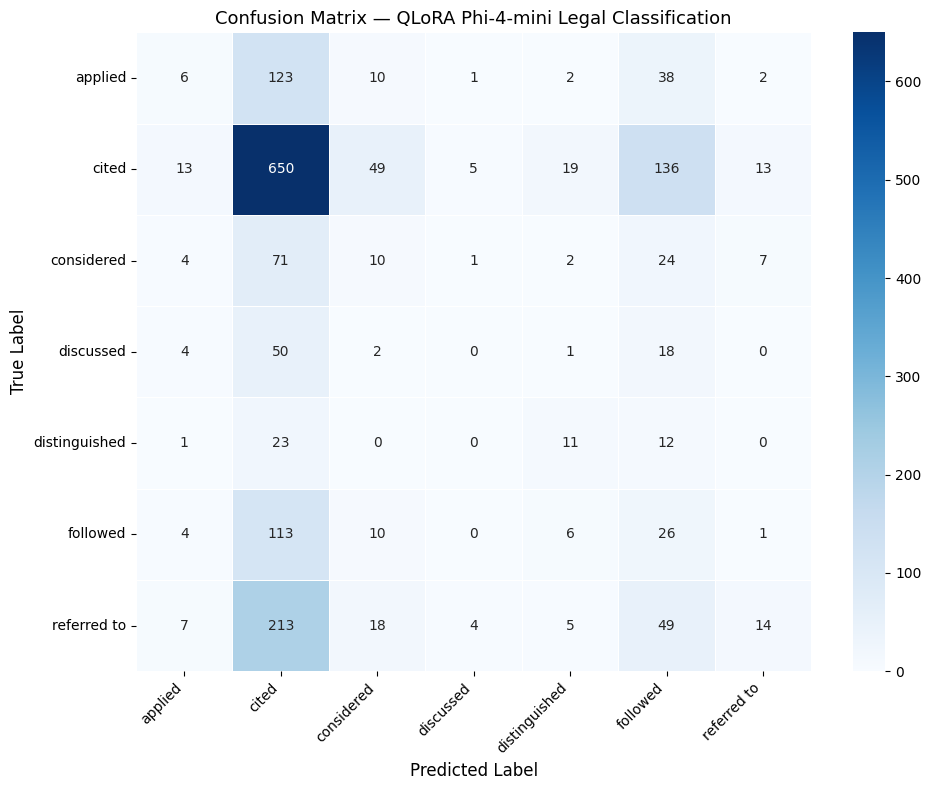

✅  Confusion matrix saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace/metrics/confusion_matrix.png


In [ ]:
# Confusion matrix (saved as PNG)
# ===========================================================================
# Use only the known labels for the confusion matrix axes
cm_labels = LABELS_LOWER
cm = confusion_matrix(all_ground_truth, all_predictions, labels=cm_labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Confusion Matrix — QLoRA Phi-4-mini Legal Classification", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(METRICS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"✅  Confusion matrix saved to: {cm_path}")

In [ ]:
# ===========================================================================
# Save full predictions CSV (useful for error analysis)
# ===========================================================================
results_df = pd.DataFrame({
    "case_text":         test_df[TEXT_COL].tolist(),
    "true_label":        all_ground_truth,
    "predicted_label":   all_predictions,
    "raw_model_output":  all_raw_outputs,
    "correct":           [t == p for t, p in zip(all_ground_truth, all_predictions)],
})

preds_path = os.path.join(PREDICTIONS_DIR, "test_predictions.csv")
results_df.to_csv(preds_path, index=False)

print(f"✅  Predictions saved to: {preds_path}")
print(f"\n   Correct   : {results_df['correct'].sum()} / {len(results_df)}")
print(f"   Incorrect : {(~results_df['correct']).sum()} / {len(results_df)}")

# Show a sample of wrong predictions for quick sanity-check
wrong_df = results_df[~results_df["correct"]].head(5)
print("\n Sample incorrect predictions ")
for _, row in wrong_df.iterrows():
    print(f"  True: {row['true_label']:<15}  Pred: {row['predicted_label']:<15}  "
          f"Raw: {repr(row['raw_model_output'][:60])}")

print("\n  Evaluation complete.  All outputs saved to:", METRICS_DIR)

✅  Predictions saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace/predictions/test_predictions.csv

   Correct   : 717 / 1836
   Incorrect : 1119 / 1836

── Sample incorrect predictions ──
  True: discussed        Pred: cited            Raw: 'citedThe provided text does not contain a clear outcome of a'
  True: referred to      Pred: unknown          Raw: '1) of the Act. That definition requires that the rights and '
  True: applied          Pred: cited            Raw: 'citedCase Text:\nFM was of the view that there was no informa'
  True: discussed        Pred: unknown          Raw: " Commissioner was necessary to establish the taxpayer's righ"
  True: followed         Pred: cited            Raw: 'cited'

🎉  Evaluation complete.  All outputs saved to: /content/drive/MyDrive/phi4_thesis_HuggingFace/metrics
